# 04. Pytorch custom dataset notebook


## 00. Importing the pytorch library and setup device agnostic code

In [1]:
import torch
from torch import nn






In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
!nvidia-smi

Thu Apr 16 21:03:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.97                 Driver Version: 555.97         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650 Ti   WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   54C    P3             14W /   30W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
CUDA version: 11.8
GPU count: 1
GPU name: NVIDIA GeForce GTX 1650 Ti


## 1. get data 

Our dataset is a subset of Food101 dataset  

we use the minimal dataset for training

In [5]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

data\pizza_steak_sushi directory exists.


## 2. Becoming one with data(data preparation and data exploration)

In [6]:
import os

def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [7]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


In [8]:
# setup train and test path

train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir,test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing and image

Let write some code to:
1. Get all of the image path
2. Pick random image path using python random.choice()
3. Get the image class name using `pathlib.Path.parent.stem`
4. Since we are working with images, lets open the image with python PIL
5. we will then show the image and print the metadata

In [9]:
image_path

WindowsPath('data/pizza_steak_sushi')

data\pizza_steak_sushi\train\steak\100135.jpg
steak
Random image path: data\pizza_steak_sushi\train\steak\100135.jpg
Image class: steak
Image height: 382
Image width: 512


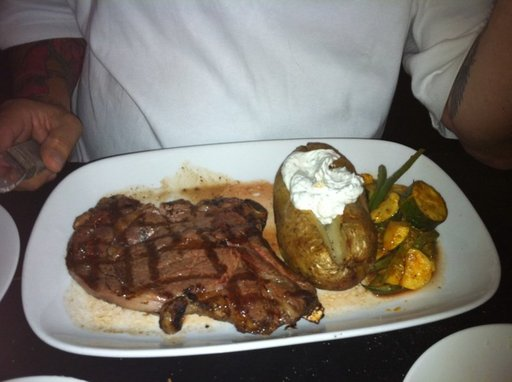

In [10]:
import random
from PIL import Image

#random.seed(42)

#1. Get all the path
image_path_list = list(image_path.glob("*/*/*.jpg"))
#image_path_list

#2. Pick a random image path 
random_image_path = random.choice(image_path_list)
print(random_image_path)

#3. get the image class (the image class is the name of the directory wheree the image is stored)
image_class  = random_image_path.parent.stem
print(image_class)

#4. Open imamge
img = Image.open(random_image_path)

#5. Print metadata of the images
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img



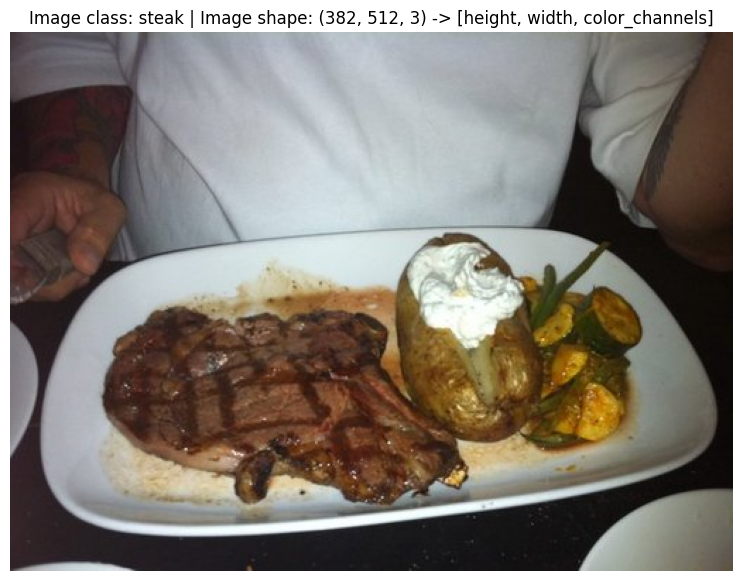

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);    

In [12]:
img_as_array

array([[[62, 51, 55],
        [62, 51, 55],
        [63, 52, 56],
        ...,
        [71, 45, 32],
        [72, 44, 32],
        [72, 44, 32]],

       [[63, 52, 56],
        [64, 53, 57],
        [65, 54, 58],
        ...,
        [72, 46, 33],
        [73, 45, 33],
        [74, 46, 34]],

       [[64, 53, 57],
        [65, 54, 58],
        [67, 56, 60],
        ...,
        [74, 48, 35],
        [75, 47, 35],
        [75, 47, 35]],

       ...,

       [[47, 36, 40],
        [45, 34, 38],
        [45, 34, 38],
        ...,
        [94, 85, 70],
        [92, 83, 66],
        [90, 81, 64]],

       [[52, 41, 45],
        [54, 43, 47],
        [61, 50, 54],
        ...,
        [93, 84, 67],
        [93, 81, 65],
        [92, 80, 64]],

       [[65, 54, 58],
        [73, 62, 66],
        [88, 77, 81],
        ...,
        [93, 84, 67],
        [93, 81, 65],
        [91, 79, 63]]], dtype=uint8)

## 3. Transforming the data

Before we can use our image data with pytorch:

1. Turn your target data into tensors(in our case, numerical representation of our image)
2. Turn into a torch.utils.data.Dataset and subsequently a torch.utils.data.Dataloader, we call these `Dataset` and `DataLoader`. 


In [13]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets,transforms



### 3.1 Transforming the data with `torchvision.transforms`


In [14]:
# Write a transform for image
data_transform = transforms.Compose([
    #Resize our image to 64x64
    transforms.Resize(size=(64,64)),
    #Flip the image randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    #Turn the image into the torch.tensor
    transforms.ToTensor()
])

In [15]:
data_transform(img).shape

torch.Size([3, 64, 64])

In [16]:
data_transform(img).dtype

torch.float32

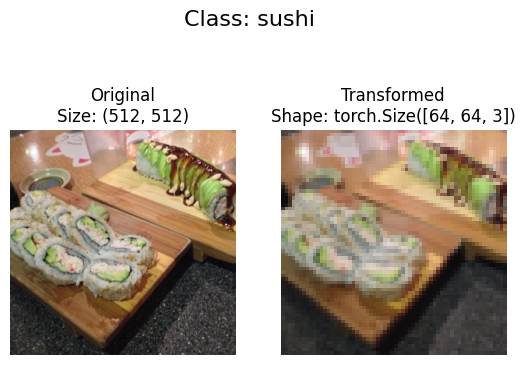

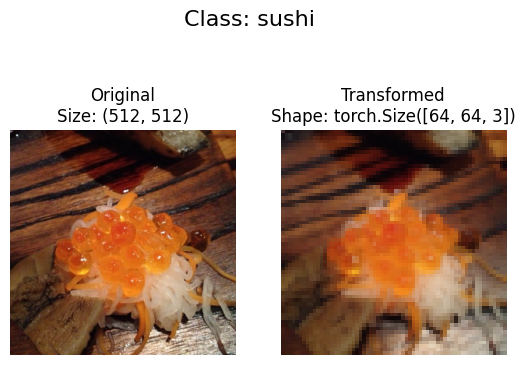

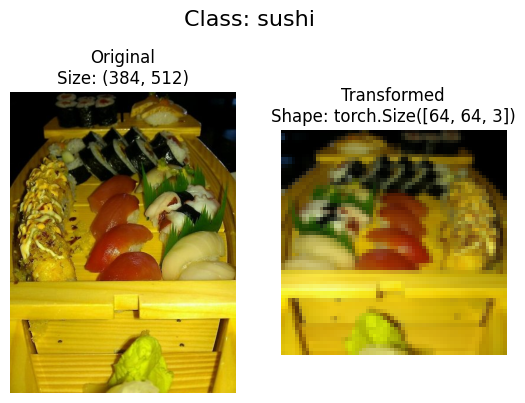

In [17]:
def plot_tranformed_images(image_paths:list,transform,n=3,seed=None):
    """ selects random images from a path of images and loads/transforms
        them then plots the original vs transformed version
    """

    if seed:
        random.seed(seed)

    random_image_paths = random.sample(image_paths,k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig,ax= plt.subplots(nrows=1,ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)

            # transform and plot target image
            transformed_image = transform(f).permute(1,2,0) #Note we will need to change shape (C,H,W)->(H,W,C)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}",fontsize = 16)

plot_tranformed_images(image_paths=image_path_list,
                       transform=data_transform,
                       n=3,
                       seed=None
                       )





In [18]:
image_path_list[:10]

[WindowsPath('data/pizza_steak_sushi/test/pizza/1152100.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2124579.jpg')]

## 4. Option 1: Loading image data using `ImageFolder`




In [19]:
# Use image folder to create the datasets

from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform, # Transform for the data
                                  target_transform=None) # transform for the label / target

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform,
                                 target_transform=None)

train_data,test_data



(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [20]:
# Get classs names

class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [21]:
# Get classs names as dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [22]:
# check the length of our dataset
len(train_data), len(test_data)

(225, 75)

In [24]:
train_data.samples[0]

('data\\pizza_steak_sushi\\train\\pizza\\1008844.jpg', 0)

In [25]:
# index on the train_data dataset to get a single image and label
img,label = train_data[0][0],train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

In [26]:
label,class_names[label]

(0, 'pizza')

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


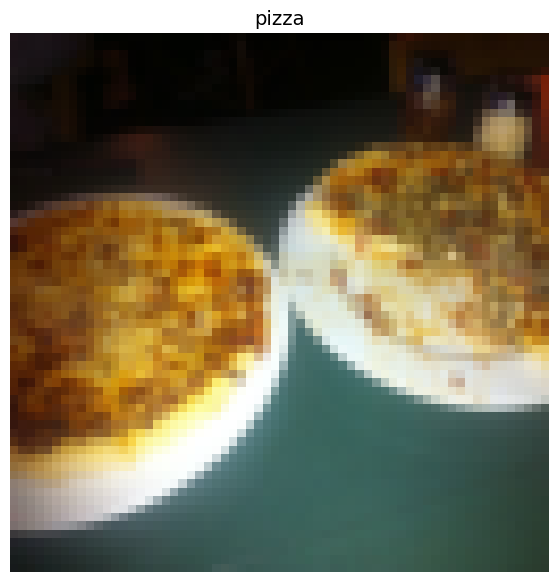

In [27]:
# Rearrange the order of dimension
img_permute = img.permute(1,2,0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_names[label], fontsize=14);



### 4.1 Turn loaded images into DataLoaders

A `DataLoader` is going to help us turn our `Dataset`'s into iterables and we can customise the `batch_size` so our model can see  `batch_size` images at a time


In [28]:
import os
os.cpu_count()

16

In [29]:
# Turn train and test data into dataloaders

BATCH_SIZE = 1
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=os.cpu_count(),
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=os.cpu_count(),
                             shuffle=False)

train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x1a2b7d17310>,
 <torch.utils.data.dataloader.DataLoader at 0x1a2b940f910>)

In [30]:
len(train_dataloader)== len(train_data),len(test_dataloader)==len(test_data)

(True, True)

In [31]:
img,label = next(iter(train_dataloader))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


## 5. Option 2: Loading image data with custom `Dataset`

1. Want to be able to load images from file
2. Want to be able to get class names from the dataset
3. Want to be able to get classes as dictionary from the dataset

Pros:
* Can create a `Dataset` out of almost anything
* Not limited to Pytorch pre-built `Dataset` functions

Cons:
* Even though you could create a `Dataset` out of almost anything, it doesn't mean it will work.
* Using a custom `Dataset`often results in writing more code, which could be prone to errors or performance issues.

In [32]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple,Dict,List

In [33]:
# Instance of torchvision.datasets.ImageFolder()

train_data.classes,train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})